In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import librosa
import tensorflow
import librosa.display
import os

In [4]:
audio="/content/drive/MyDrive/genres_original"

data=[]
labels=[]
genres=os.listdir(audio)

for i in genres:
    genre_path=os.path.join(audio,i)
    for file_name in os.listdir(genre_path):
        file_path=os.path.join(genre_path, file_name)
        if file_path.endswith((".wav", ".mp3", ".au")):
            try:
                y, sr = librosa.load(file_path, duration=30)

                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = np.mean(mfcc.T, axis=0)

                chroma = librosa.feature.chroma_stft(y=y, sr=sr)
                chroma_mean = np.mean(chroma.T, axis=0)

                contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
                contrast_mean = np.mean(contrast.T, axis=0)

                features = np.concatenate([mfcc_mean, chroma_mean, contrast_mean])

                data.append(features)
                labels.append(i)
            except Exception as e:
                print("Could not process:", file_path, "Error:", e)


/tmp/ipykernel_1270/1213374760.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Could not process: /content/drive/MyDrive/genres_original/jazz/jazz.00054.wav Error: 


In [5]:
X = pd.DataFrame(data)
y = pd.Series(labels)

print(X.shape)
print(y.shape)

(999, 32)
(999,)


In [6]:
en=LabelEncoder()
y_encoded=en.fit_transform(y)

In [20]:
x_train,x_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.3,random_state=42)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [ ]:
from catboost import CatBoostClassifier
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.5,
    depth=6
)
model.fit(x_train,y_train)

In [80]:
from sklearn.metrics import accuracy_score
pred=model.predict(x_test)
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))
print(accuracy_score(y_test,pred))

1.0
0.69
0.69


In [76]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)

model2.fit(X_train, y_train)

RandomForestClassifier(n_estimators=400, random_state=42)

In [77]:
y_pred = model2.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6166666666666667


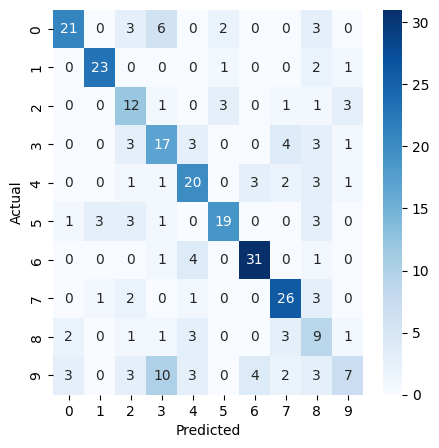

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

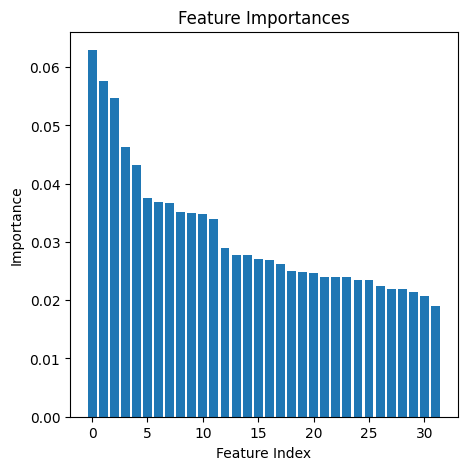

In [90]:
importances = model2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(5,5))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()